# Linear Regression Lab

data set: USA_Housing.csv.

The data contains the following columns:

* 'Avg. Area Income': Avg. Income of residents of the city house is located in.
* 'Avg. Area House Age': Avg Age of Houses in same city
* 'Avg. Area Number of Rooms': Avg Number of Rooms for Houses in same city
* 'Avg. Area Number of Bedrooms': Avg Number of Bedrooms for Houses in same city
* 'Area Population': Population of city house is located in
* 'Price': Price that the house sold at
* 'Address': Address for the house

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the file

In [ ]:
df = pd.read_csv("USA_Housing.csv")
df

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
...,...,...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316


Use head, describe and info to get to know the data

In [ ]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [ ]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


use pairplot to find correlations

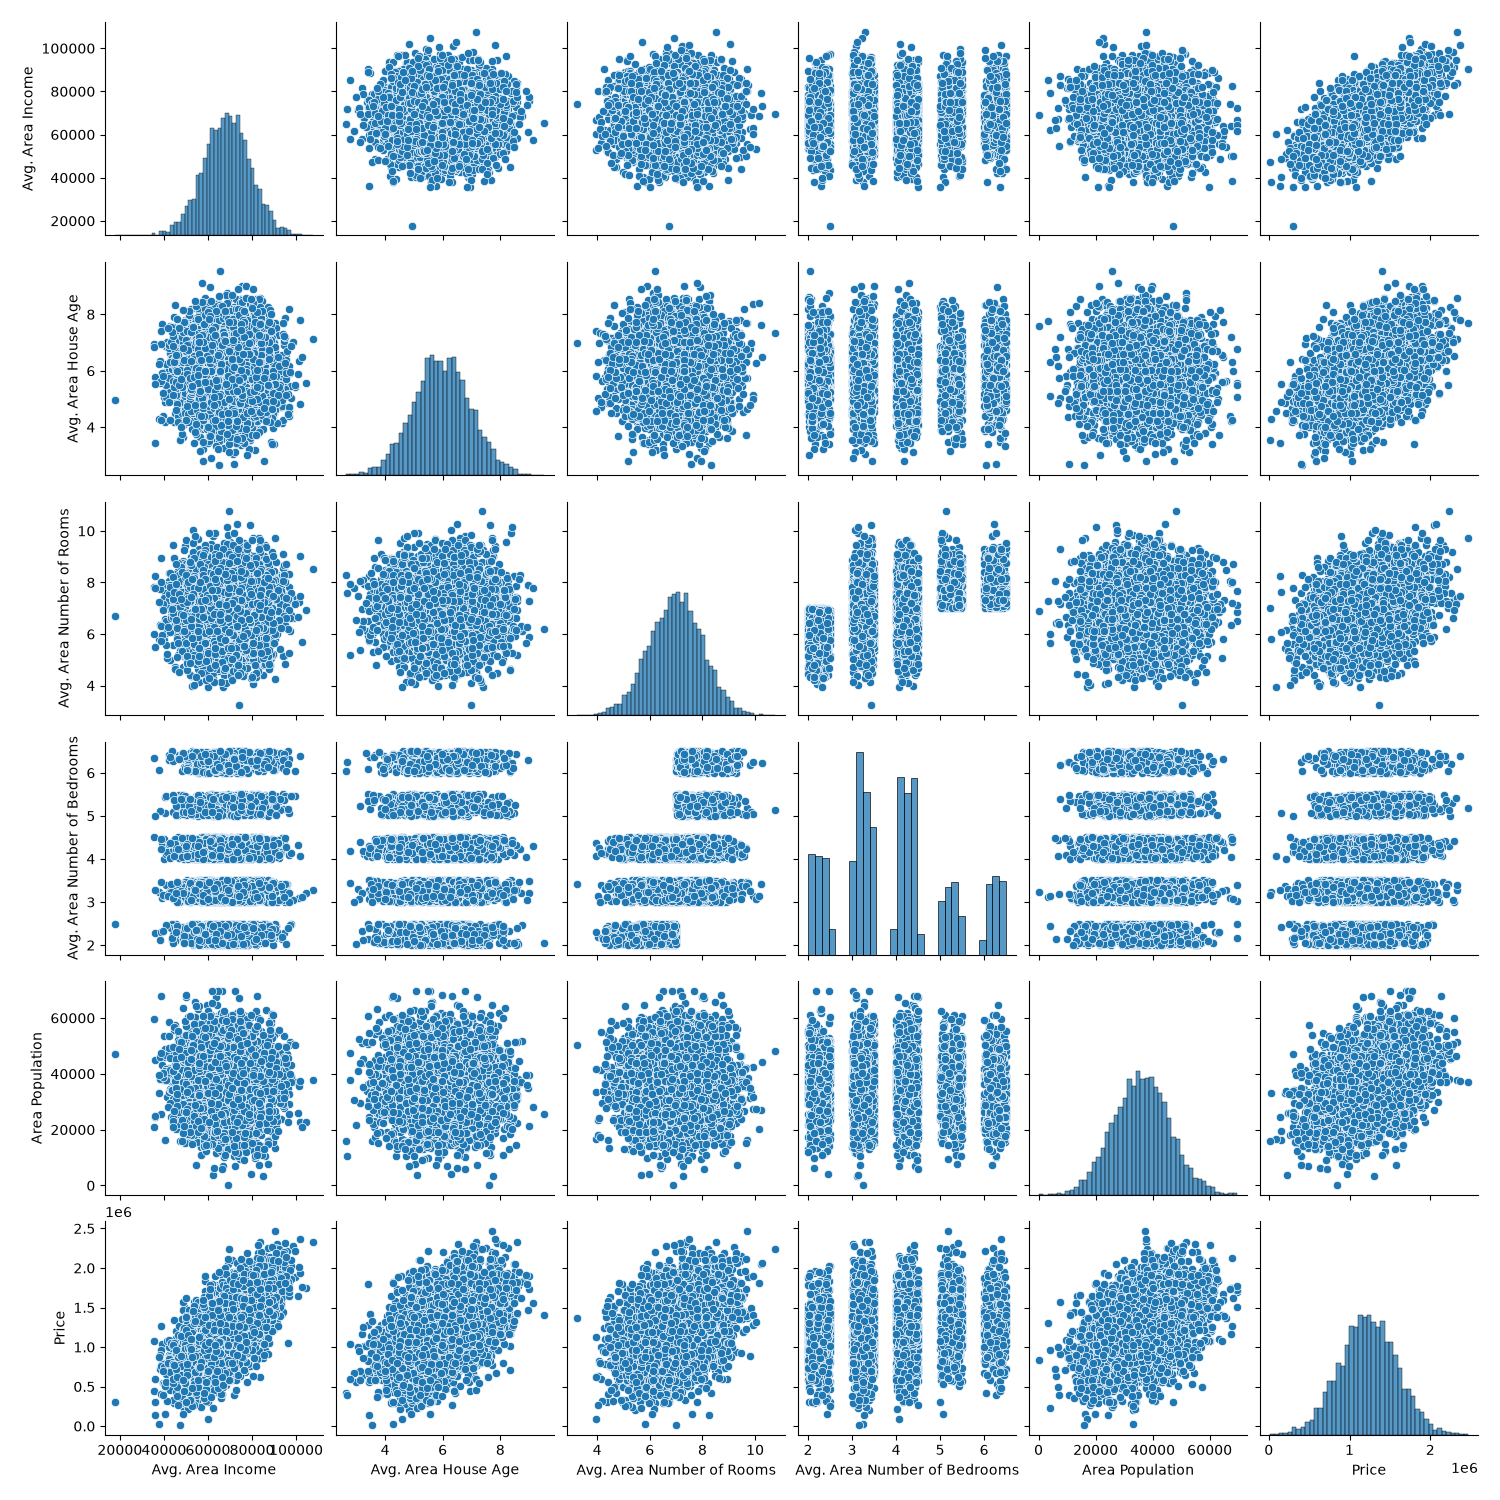

In [ ]:
sns.pairplot(df)

Use distplot to find the pricing distribution

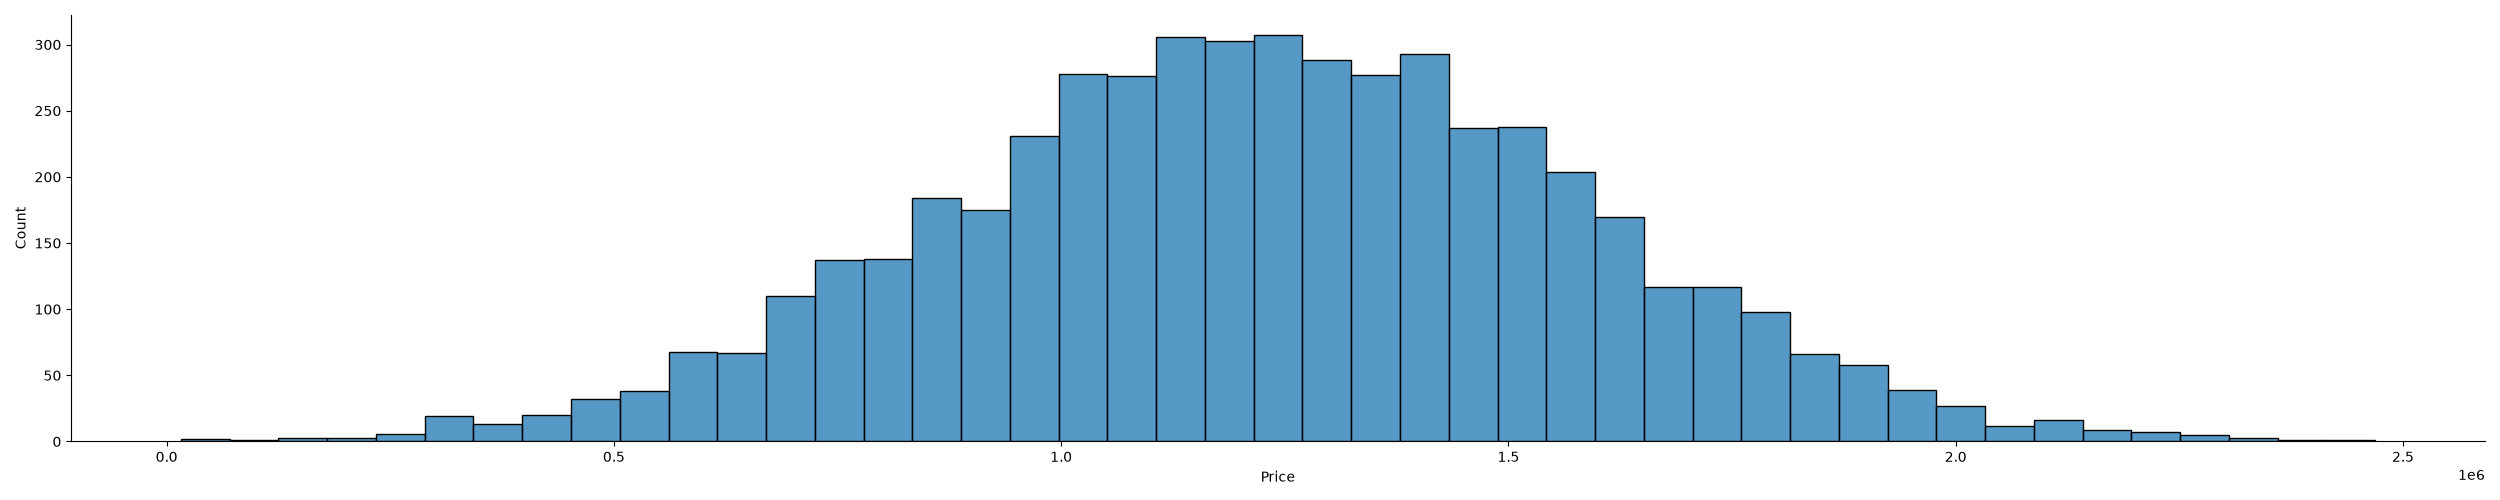

In [ ]:
sns.displot(data=df, x="Price", aspect=5);

Display data correlation

In [ ]:
df.corr(numeric_only=True).round(2)

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
Avg. Area Income,1.00,-0.00,-0.01,0.02,-0.02,0.64
Avg. Area House Age,-0.00,1.00,-0.01,0.01,-0.02,0.45
Avg. Area Number of Rooms,-0.01,-0.01,1.00,0.46,0.00,0.34
Avg. Area Number of Bedrooms,0.02,0.01,0.46,1.00,-0.02,0.17
Area Population,-0.02,-0.02,0.00,-0.02,1.00,0.41
Price,0.64,0.45,0.34,0.17,0.41,1.00


Display correlation with heatmap

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

<Axes: >

# training
Create an X array that contains the features to train on, and a y array with the target variable - the Price column.<br>
Remove any non valuable data

In [ ]:
x = df.drop(columns=['Price', 'Address'])
y = df['Price']

## Train Test Split

Use sklearn.model_selection.train_test_split to split the data (train/test)

In [ ]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((4000, 5), (1000, 5), (4000,), (1000,))

Create and Train the Model

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse, r2

(10089009300.894016, 0.9179971706834329)

Display the model intercept and coefficient

In [ ]:
model.intercept_
model.coef_ 

array([2.16522058e+01, 1.64666481e+05, 1.19624012e+05, 2.44037761e+03,
       1.52703134e+01])

## Testing Model

predict the test set

In [ ]:
model.predict(x_test)

array([1308587.92699753, 1237037.22949429, 1243429.34030687,
       1228900.21360378, 1063320.90710821, 1544058.05034856,
       1094774.70493022,  833284.72339228,  788412.85578723,
       1469714.86615707,  671728.43662065, 1606818.21977937,
       1004166.61331062, 1796798.97595927, 1288566.96221017,
       1087782.93301077, 1423072.37492527, 1078178.68169674,
        802286.03537901,  930761.03695713, 1134829.86477819,
        916398.42023136, 1489972.69335423, 1284580.15538819,
       1582071.35322731, 1132519.15991993, 1089888.39644513,
        974510.51872158,  924057.96820667, 1740759.72092273,
       1286481.5951232 , 1621289.9517161 , 1435264.20161716,
       1234014.77924483, 1485434.57300369, 1718335.00753688,
       1538953.74882847,  777106.64791795, 1765201.52243617,
       1175972.1419982 , 1553707.94323484,  897703.67505177,
       1371049.80326608,  845281.72310358, 1201022.89803884,
       1133285.98450857, 1363128.14557352, 1449814.0876827 ,
       1574363.90467353,

Use scatter graph with the test and the predictions

In [ ]:
sns.scatterplot(x=y_test, y=y_pred)

<Axes: xlabel='Price'>

**Residual Histogram**<br>
Create distplot with 50 bins for the error (real value - predicted)

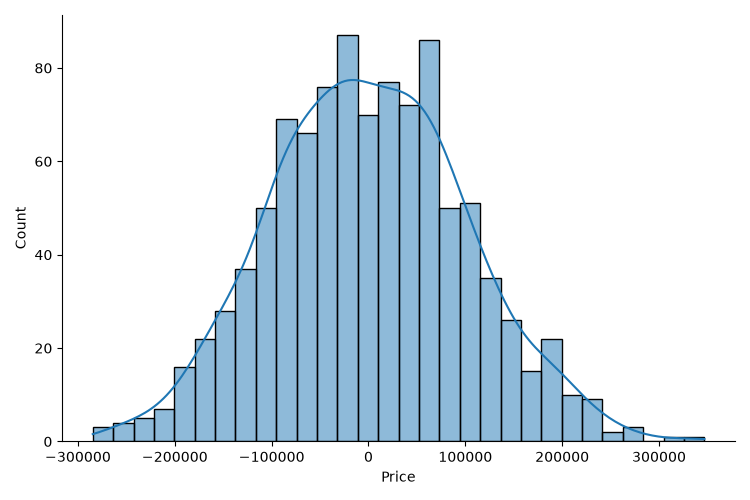

In [ ]:
sns.displot(y_test - y_pred, kde=True, bins=30, aspect=1.5)

Estimate the value of the following house:<br>
* 6 rooms
* 4 bedrooms
* Area income: 80000
* 5 years old
* Area population: 20000

In [ ]:
new_house = pd.DataFrame({
    "Avg. Area Number of Rooms": [6],
    "Avg. Area Number of Bedrooms": [4],
    "Avg. Area Income": [80000],
    "Avg. Area House Age": [5],
    "Area Population": [20000]
})

In [ ]:
predicted_price = model.predict(new_house[x_train.columns])
predicted_price

array([953347.81620189])

### Intuition on what is a model
 
1. select the 2 best features
2. create a linear model
3. train the model
4. draw the model as a 3d plane on the data
 

In [ ]:
features = ["Avg. Area Income", "Avg. Area House Age"]

x_train_2 = x_train[features]

In [ ]:
model_2 = LinearRegression()

In [ ]:
model_2.fit(x_train_2, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 21.26,160651.75]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Avg. Area Income','Avg. Area House Age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.188e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [ ]:
%matplotlib ipympl

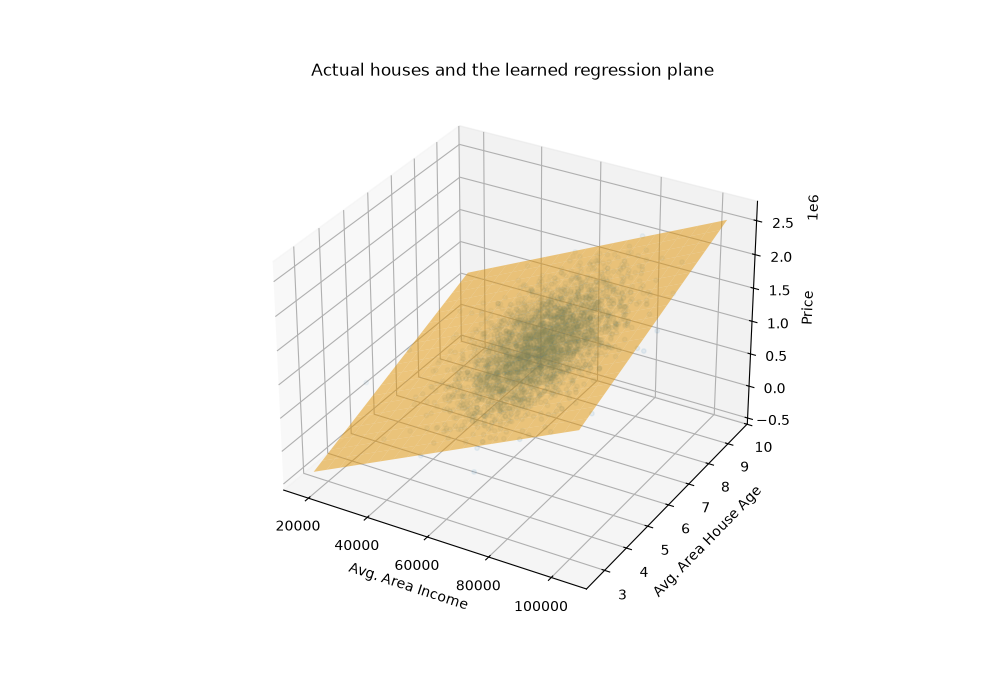

In [ ]:
income_values = np.linspace(
    x_train_2[features[0]].min(),
    x_train_2[features[0]].max(),
    20
)

age_values = np.linspace(
    x_train_2[features[1]].min(),
    x_train_2[features[1]].max(),
    20
)

income_grid, age_grid = np.meshgrid(income_values, age_values)

grid_houses = pd.DataFrame({
    features[0]: income_grid.ravel(),
    features[1]: age_grid.ravel()
})

price_grid = model_2.predict(grid_houses).reshape(income_grid.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    income_grid,
    age_grid,
    price_grid,
    color="orange",
    alpha=0.5
)

ax.set_xlabel("Avg. Area Income")
ax.set_ylabel("Avg. Area House Age")
ax.set_zlabel("Price")
ax.set_title("Actual houses and the learned regression plane")

ax.scatter(
    x_train_2[features[0]],
    x_train_2[features[1]],
    y_train,
    s=10,
    alpha=0.3
)